# Notebook for constructing age models for the Mamainse Point Volcanics

In [2]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/0000_Github/APWP_StratModels/code`
┌ Warning: The active manifest file has dependencies that were resolved with a different julia version (1.11.6). Unexpected behavior may occur.
└ @ nothing /Users/unimos/0000_Github/APWP_StratModels/code/Manifest.toml:0
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API /Users/unimos/.julia/juliaup/julia-1.12.4+0.aarch64.apple.darwin14/share/julia/stdlib/v1.12/Pkg/src/API.jl:1308
Precompiling packages...
              ✗ MbedTLS
              ✗ HTTP
              ✗ FileIO → HTTPExt
  0 dependencies successfully precompiled in 6 seconds. 373 already precompiled.


plot_posterior_paths (generic function with 1 method)

## Maminase Point Volcanics

- The bottom of the section is in the lowermost Alona Bay reversed polarity zone associated with the onset of Midcontinent Rift volcanism. This onset is not particularly well-dated with the best constraints coming from early rift intrusions such as the 1109.0±1.3 Ma Sunday Lake intrusion (Bleeker et al., 2020).
- We know that the first site of the lower normal polarity zone (the Flour Bay normal polarity zone) at stratigraphic height of 1351 m is younger than 1105.15±0.33 Ma which is the date of a rhyolite from Agate Point in the Osler Volcanic Group which is within the Alona Bay reversed polarity zone.
- The Flour Bay Tuff is dated to be 1100.36 $\pm$ 0.25 Ma which can be used as an absolute constraint at strat height of 1970 m.
- The top of the section is of normal polarity with no radiometric constraints. The youngest dated flow during the period of massive basaltic volcanism is the Greenstone Flow (1091.59 ± 0.27 Ma; Swanson-Hysell et al., 2019), let's set it to be 1091 $\pm$ 4 Ma to allow for many different scenarios of eruption rate at Mamainse Point.

In [5]:
Mamainse_Name = ("Oldest magmatism", "Max age on normal polarity", "Flour Bay tuff", "Top of Mamainse") # Et cetera
Mamainse_Age           = [ 1109, 1105.15,1100.36, 1090] # Measured ages
Mamainse_Age_sigma     = [ 1.3/2, 0.33/2, 0.25/2, 4/2] # Measured 1-σ uncertainties
Mamainse_Height        = [ 0.0, 1351,  1970,  4100] # Depths below surface should be negative
Mamainse_Age_Sidedness = [0, -1, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Mamainse_Path = "../../data/age_models_output/Mamainse_Point_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Mamainse_section = make_ChronAgeData(Mamainse_Name, Mamainse_Age, Mamainse_Age_sigma, Mamainse_Height, Mamainse_Age_Sidedness, Mamainse_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{4}(("Oldest magmatism", "Max age on normal polarity", "Flour Bay tuff", "Top of Mamainse"), [0.0, 1351.0, 1970.0, 4100.0], [0.01, 0.01, 0.01, 0.01], [1109.0, 1105.15, 1100.36, 1090.0], [0.65, 0.165, 0.125, 2.0], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN], [0.0, -1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN NaN; NaN NaN NaN NaN; … ; NaN NaN NaN NaN; NaN NaN NaN NaN], "../../data/age_models_output/Mamainse_Point_Volcanic_Group", 2, "Ma", "m", :cdf)

In [6]:
Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, Mamainse_age_model_lldist = run_age_model(Mamainse_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/unimos/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 575000 steps
└ @ Chron /Users/unimos/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 575000 steps
└ @ Chron /Users/unimos/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 575000, 1000, 575, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  4010.0, 4020.0, 4030.0, 4040.0, 4050.0, 4060.0, 4070.0, 4080.0, 4090.0, 4100.0], [1109.0116785711816, 1108.9659817801764, 1108.919632114223, 1108.8636813788926, 1108.793309230196, 1108.7340475012263, 1108.682247703633, 1108.6232943309888, 1108.5550011565874, 1108.513956733555  …  1090.485906605585, 1090.4387618673477, 1090.391371303844, 1090.3468001587867, 1090.310232072327, 1090.2632513953388, 1090.2267238231952, 1090.1799340836367, 1090.1172245563298, 1090.0726899387557], [0.6238789191684839, 0.6637208560692831, 0.7152282884921459, 0.7654217831654387, 0.8302742685277719, 0.8622537707566721, 0.8998558749794773, 0.9295273565210145, 0.9667574788825793, 0.986832918627159  …  1.599516199196286, 1.578633289312685, 1.557434002204198, 1.543534548329393, 1.5278450648110173, 1.516906615154484, 1.4969092559797514, 1.477292885231938, 1.4307120564960518, 1.410067

### posterior summary age model

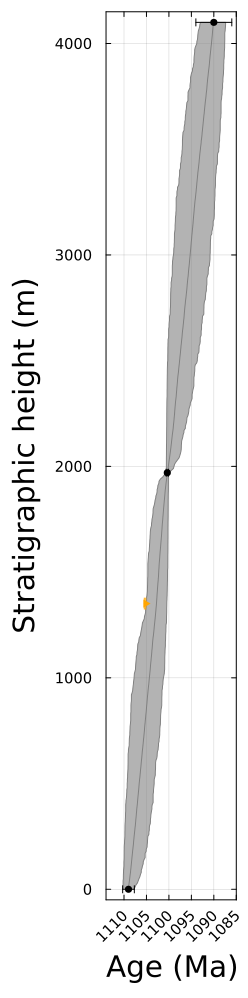

In [7]:
Mamainse_age_model = plot_age_model(Mamainse_section, Mamainse_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 4150), xlim=(1085, 1114), legend=false, left_margin = 12Plots.mm, guidefontsize=20, size=(250, 1000))
savefig(Mamainse_age_model, Mamainse_section.Path*"_AgeDepthModel.pdf")
display(Mamainse_age_model)

### example posterior accumulation models

agemin: 1090.0726899387557, agemax: 1109.0116785711816, halfw: 0.25, Δt: 0.1
Number of windows: 185
  0.167261 seconds (9.00 k allocations: 10.437 MiB)


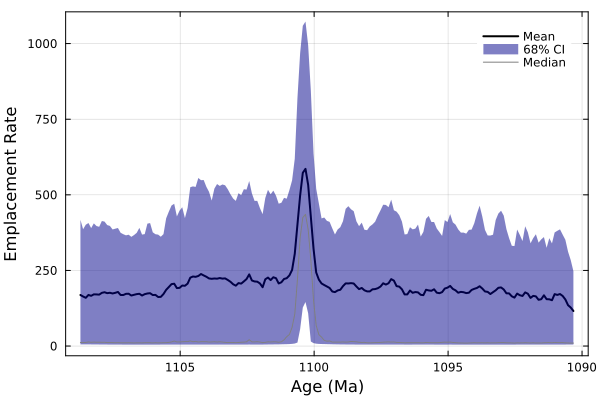

In [8]:
plot_accumulation_model(Mamainse_section, Mamainse_age_model_config, Mamainse_age_model_mdl, Mamainse_age_model_agedist, binwidth=0.5, stepfrac=0.2, save_figure=false)

### example posterior age models

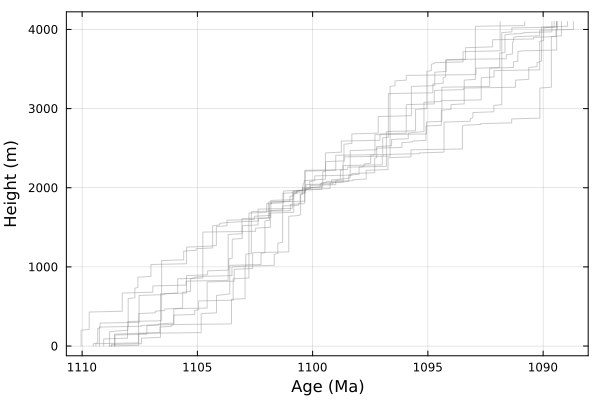

In [9]:
plot_posterior_paths(Mamainse_section, Mamainse_age_model_agedist, Mamainse_age_model_mdl)

## save the age models to a file

In [7]:
# use the mdl.height as index, agedist as the data
Mamainse_age_models_df = DataFrame(hcat(Mamainse_age_model_mdl.Height, Mamainse_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Mamainse_age_models_df, Dict(:x1 => "height"))
Mamainse_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.6,1109.57,1112.08,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1110.74,1108.56,1108.96,1110.76,1108.2,1109.13,1110.42,1109.56,1109.6,1109.43,1108.04,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1109.81,1111.37,1109.0,1107.81,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1110.78,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.53,1110.81,1109.49,1109.52,1110.08,1111.13,1109.86,1109.64,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1109.44,1111.53,⋯
2,10.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1109.38,1108.56,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1108.04,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1109.81,1111.37,1109.0,1107.81,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1110.78,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.36,1110.81,1109.49,1109.52,1109.93,1111.13,1109.86,1109.36,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1107.57,1111.53,⋯
3,20.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.48,1111.63,1109.52,1109.82,1109.81,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1108.8,1108.39,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1107.67,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1107.88,1111.37,1109.0,1107.71,1109.35,1110.0,1111.45,1110.4,1111.52,1110.59,1108.47,1109.06,1110.28,1110.94,1110.49,1110.23,1108.05,1109.81,1109.67,1110.39,1109.9,1108.69,1110.0,1109.28,1110.13,1109.07,1108.53,1110.09,1110.18,1109.36,1110.81,1109.49,1109.52,1109.93,1111.13,1109.86,1109.36,1111.14,1111.1,1109.63,1111.29,1109.53,1111.99,1108.84,1110.91,1109.97,1109.44,1109.48,1109.23,1108.26,1106.88,1111.53,⋯
4,30.0,1110.13,1110.98,1109.88,1109.88,1109.55,1110.2,1109.57,1111.53,1110.73,1109.24,1109.96,1110.84,1110.04,1111.35,1111.63,1109.52,1108.26,1109.8,1108.4,1109.93,1110.35,1110.72,1109.83,1109.55,1109.54,1111.38,1110.29,1108.8,1108.39,1108.96,1110.76,1107.67,1109.13,1110.42,1109.56,1109.6,1109.43,1107.67,1110.19,1110.71,1110.89,1109.46,1109.56,1108.92,1109.27,1109.13,1109.81,1107.88,1111.37,1109.0,1107.71,1109.35,1110.

In [8]:
# write the DataFrame to a csv file
CSV.write(Mamainse_section.Path*"_posterior_ages.csv", Mamainse_age_models_df)

"../../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv"